In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
ct_path = Path(r"D:\ProyectoAnalisisElectrico\CupraThermV2\Resumen_Establecimientos.csv")
dfy_path = Path(r"D:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2505_2604\2505_2604_mean_period_loc.parquet")
dfo_path = Path(r"D:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2505_2604_otono\2505_2604_otono_mean_period.parquet")
dfi_path = Path(r"D:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2507_2509_invierno\2507_2509_invierno_mean_period.parquet")
dfp_path = Path(r"D:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2510_2512_primavera\2510_2512_primavera_mean_period.parquet")
dfv_path = Path(r"D:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2601_2603_verano\2601_2603_verano_mean_period.parquet")

ct = pd.read_csv(ct_path,sep=",")
dfy = pd.read_parquet(dfy_path)
dfo = pd.read_parquet(dfo_path)
dfi = pd.read_parquet(dfi_path)
dfv = pd.read_parquet(dfv_path)
dfp = pd.read_parquet(dfp_path)
dfs = [dfy,dfo,dfi,dfv,dfp]

In [8]:
ct.columns

Index(['CODIGO_VU', 'RAZON_SOCIAL', 'RUT_RAZON_SOCIAL',
       'NOMBRE_ESTABLECIMIENTO', 'COMBUSTIBLE_PRIMARIO', 'LATITUD', 'LONGITUD',
       'REGION', 'RUBRO', 'CIIU6', 'DEMANDA_CALOR_MWH', 'CALNUM', 'Acrolein',
       'Arsenic', 'Benzene', 'Cadmium', 'Carbon dioxide', 'Carbon monoxide',
       'Formaldehyde', 'Lead', 'Mercury', 'Methane', 'Nitrogen oxides (NOx)',
       'Nitrous oxide', 'Pentachlorophenol (PCP)', 'Sulfur dioxide', 'Toluene',
       'Volatile organic compounds (VOC)', 'Black Carbon', 'PCDD-F',
       'Sulfur oxides (SOx)', 'Ammonia', 'PM, primary', 'PM10, primary',
       'PM2.5, primary'],
      dtype='object')

In [3]:
conteos = ct.groupby(["REGION", "RUT_RAZON_SOCIAL"]).size().reset_index(name='cantidad_elementos')

In [8]:
ct.head()

,CODIGO_VU,RAZON_SOCIAL,RUT_RAZON_SOCIAL,NOMBRE_ESTABLECIMIENTO,COMBUSTIBLE_PRIMARIO,LATITUD,LONGITUD,REGION,RUBRO,CIIU6,...,Sulfur dioxide,Toluene,Volatile organic compounds (VOC),Black Carbon,PCDD-F,Sulfur oxides (SOx),Ammonia,"PM, primary","PM10, primary","PM2.5, primary"
0,2856,A IMPRESORES S.A.,96830710-K,A Impresores,Gas Natural,-35.675145,-71.542965,Metropolitana de Santiago,Otras industrias manufactureras,Impresión de libros,...,3.142660e-04,0.000002,0.002881,0.000022,0.000000e+00,0.0,0.000257,0.003981,0.003981,0.003981
1,5441850,ABICK S.A.,76113326-8,PLANTA DALCAHUE,Gas Licuado de Petróleo,-42.387435,-73.666765,Los Lagos,Otras industrias manufactureras,Elaboración y conservación de salmónidos,...,3.440000e-07,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000265,0.000265
2,5473543,ACF BAQUEDANO S.A,77209907-K,PLANTA DE NITRATOS Y PRODUCTOS DERIVADOS DE SALES,Gas Natural,-23.265766,-69.805136,Antofagasta,Minería,Extracción de minerales para la fabricación de...,...,1.182570e+00,0.000000,0.000000,0.004827,2.770000e-09,0.0,0.000000,0.000000,998.614560,998.614560
3,5493389,ACF BAQUEDANO S.A,77209907-K,ACF BAQUEDANO S.A.,Varios,-20.978247,-69.674593,Tarapacá,Minería,Extracción de minerales para la fabricación de...,...,1.487484e-02,0.002590,0.009570,0.110081,5.831200e-09,0.0,0.240486,0.013224,1.232570,0.962167
4,6488,ACF MINERA S.A.,79728000-3,ACF MINERA S.A.,Petróleo N 2 (Diesel),-21.056557,-69.609475,Tarapacá,Minería,Extracción de minerales para la fabricación de...,...,2.570000e-06,0.000000,0.000000,0.000005,2.120000e-13,0.0,0.000048,0.000000,0.000139,0.000094


In [7]:
ct[ct["RUT_RAZON_SOCIAL"] == "50004640-6"]

,CODIGO_VU,RAZON_SOCIAL,RUT_RAZON_SOCIAL,NOMBRE_ESTABLECIMIENTO,COMBUSTIBLE_PRIMARIO,LATITUD,LONGITUD,REGION,RUBRO,CIIU6,...,Sulfur dioxide,Toluene,Volatile organic compounds (VOC),Black Carbon,PCDD-F,Sulfur oxides (SOx),Ammonia,"PM, primary","PM10, primary","PM2.5, primary"


In [9]:
dfy[dfy["RUT"] == "50.004.640-6"]

,clave,Zona,Hora,active_calendar,RUT,rut_log,n_ruts,Razon_Social,razon_social_log,n_razones_sociales,...,CMg[CLP/KWh]_std,CMg[CLP/KWh]_count,valorizado_CLP_mean,valorizado_CLP_std,valorizado_CLP_count,medida_total,region,macrozona,confianza,IA


In [10]:
dfy.head()

,clave,Zona,Hora,active_calendar,RUT,rut_log,n_ruts,Razon_Social,razon_social_log,n_razones_sociales,...,CMg[CLP/KWh]_std,CMg[CLP/KWh]_count,valorizado_CLP_mean,valorizado_CLP_std,valorizado_CLP_count,medida_total,region,macrozona,confianza,IA
0,$C$439,Norte,0,111111111111,96.505.760-9,96.505.760-9,1,Colbún S.A.,Colbún S.A.,1,...,28.893765,365,-1.071117e+06,548120.866499,365,-373927.649231,Antofagasta,Norte Grande,100.0,False
1,$C$439,Norte,1,111111111111,96.505.760-9,96.505.760-9,1,Colbún S.A.,Colbún S.A.,1,...,26.857940,365,-1.043339e+06,510586.365746,365,-373927.649231,Antofagasta,Norte Grande,100.0,False
2,$C$439,Norte,2,111111111111,96.505.760-9,96.505.760-9,1,Colbún S.A.,Colbún S.A.,1,...,29.019703,365,-1.017505e+06,531921.939887,365,-373927.649231,Antofagasta,Norte Grande,100.0,False
3,$C$439,Norte,3,111111111111,96.505.760-9,96.505.760-9,1,Colbún S.A.,Colbún S.A.,1,...,33.489338,365,-1.052726e+06,557024.101790,365,-373927.649231,Antofagasta,Norte Grande,100.0,False
4,$C$439,Norte,4,111111111111,96.505.760-9,96.505.760-9,1,Colbún S.A.,Colbún S.A.,1,...,29.518448,365,-1.043940e+06,476478.617274,365,-373927.649231,Antofagasta,Norte Grande,100.0,False


In [5]:
len(conteos[conteos["cantidad_elementos"]>1])

57

In [26]:
rut = "76.858.530-K"
#rut = "87.756.500-9"

In [27]:
claves_check = dfy[dfy["RUT"] == rut]["clave"].unique()
#claves_check = dfy[dfy["RUT"] == rut].drop_duplicates(subset="tension")


In [ ]:
#claves_check[["clave", "tension"]]

,clave,tension
14256,15832215198RC,110
69840,ACF1_VIC,220


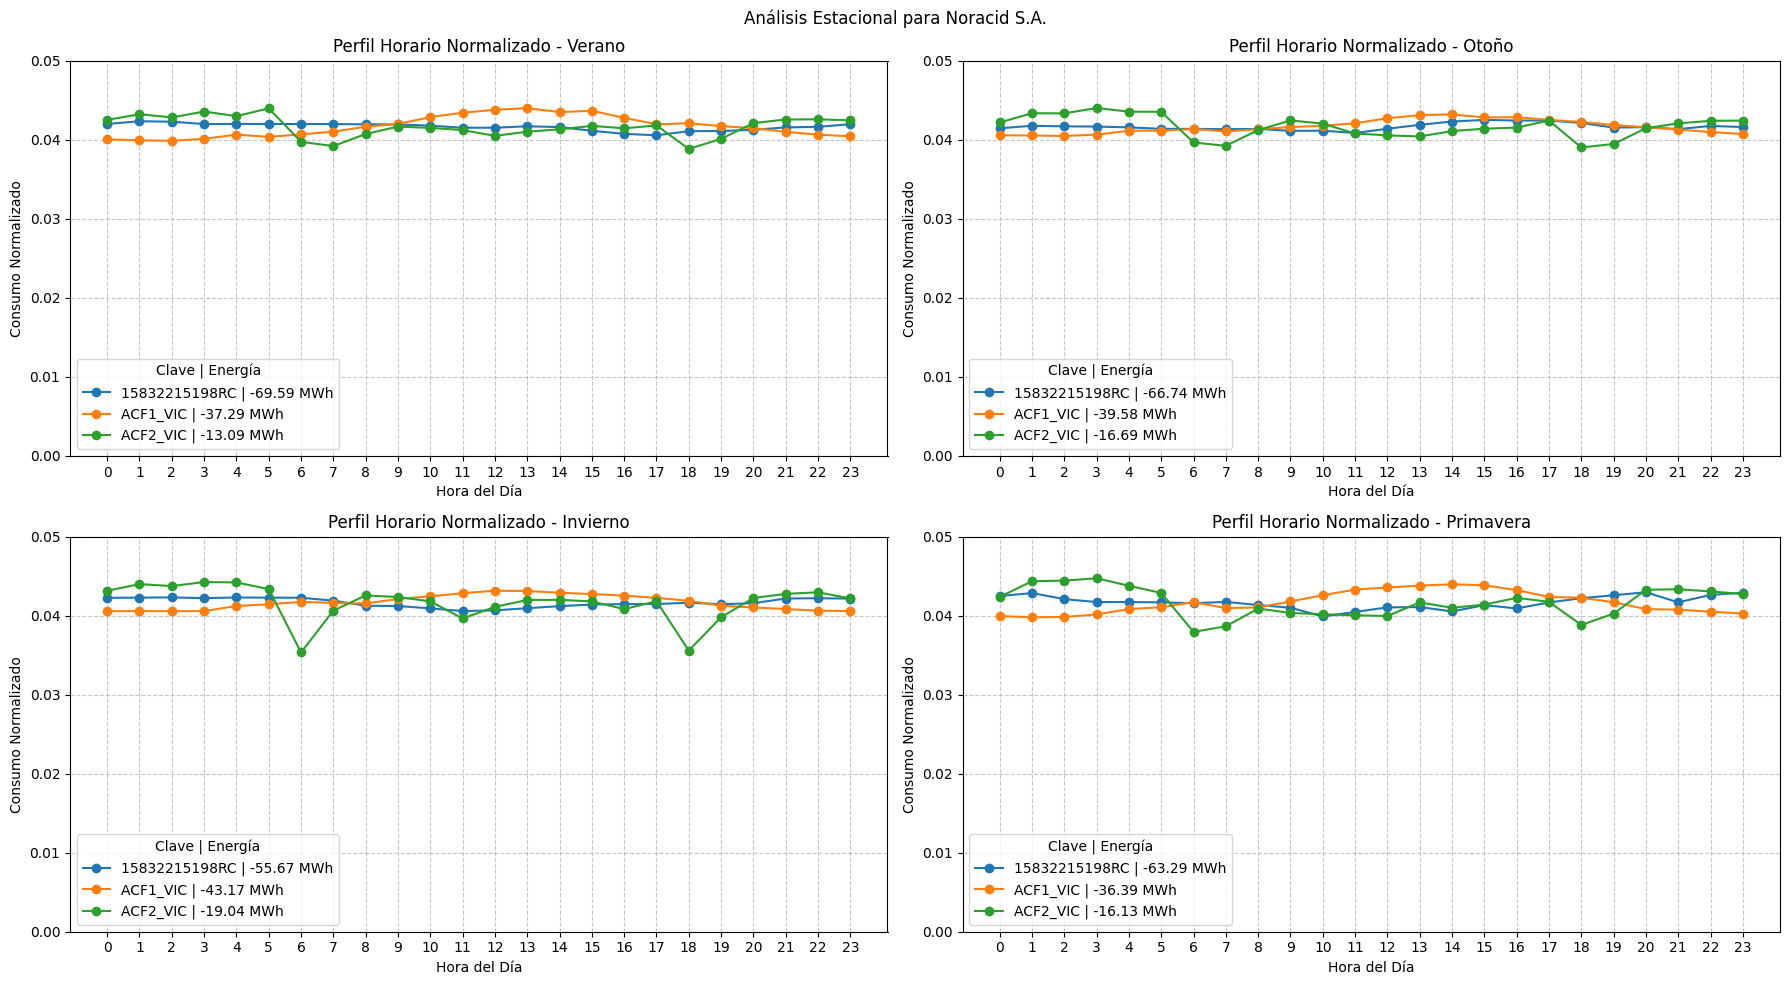

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

estaciones = [
    (dfv, "Verano", axes[0, 0]),
    (dfo, "Otoño", axes[0, 1]),
    (dfi, "Invierno", axes[1, 0]),
    (dfp, "Primavera", axes[1, 1])
]

for df_estacion, nombre, ax in estaciones:
    for clave in claves_check:
        df_clave = df_estacion[(df_estacion["RUT"] == rut) & (df_estacion["clave"] == clave)].sort_values("Hora")
        
        if not df_clave.empty:
            horas = df_clave["Hora"]
            datos_horarios = df_clave["medida_mean"] 
            total = datos_horarios.sum()
            
            datos_normalizados = datos_horarios / total
            
            ax.plot(horas, datos_normalizados, label=f"{clave} | {round(total/1000,2)} MWh", marker='o')

    ax.set_title(f"Perfil Horario Normalizado - {nombre}")
    ax.set_xlabel("Hora del Día")
    ax.set_ylabel("Consumo Normalizado")
    ax.legend(title="Clave | Energía")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks(range(0, 24))
    ax.set_ylim(0, 0.05)

plt.suptitle(f"Análisis Estacional para {dfy[dfy["RUT"] == rut]["Razon_Social"].drop_duplicates().iloc[0]}")
plt.tight_layout()
plt.show()

In [50]:
dfy[dfy["RUT"] == rut].drop_duplicates(subset=["clave"])["nombre_barra"]

93648    PETROPOWER
93696    TORQUEMADA
Name: nombre_barra, dtype: str

In [ ]:
d